<a href="https://colab.research.google.com/github/parviza9999/InterviewN/blob/main/TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Scikit-learn**

* Traditional data (like spreadsheets) rather than deep learning,
scikit-learn is the industry standard.

* Excellent for tasks like regression, classification, and clustering on small to medium-sized datasets.

* scikit-learn supports basic neural networks, but it is limited to a specific type called a Multi-layer Perceptron (MLP).

* Cannot build complex architectures like Convolutional Neural Networks (CNNs) or Recurrent Neural Networks (RNNs).

* No GPU Support: Unlike the deep learning frameworks, scikit-learn typically runs on CPUs and does not use neural networks.

* TensorFlow and PyTorch use CUDA and ROCm to offload this work to GPUs, which are hundreds of times faster than CPUs for these specific tasks.

* Scikit-learn: It uses hard-coded mathematical solvers for its specific MLP implementation.

* **TensorFlow** and PyTorch automatically calculate the math for any crazy architecture you dream up, no matter how complex.


**TensorFlow and PyTorch**

* Before libraries like TensorFlow or PyTorch, training deep learning models required writing the backpropagation (the math used to update network weights) by hand.

* TensorFlow is a free, open-source software library developed by Google.
A flexible ecosystem of tools and libraries that allow developers to build, train, and deploy sophisticated deep learning models across various environments.

* CPU, GPU and TPU support

* PyTorch developed primarily by Meta AI

* PyTorch is the most direct competitor to TensorFlow.

* More popular in research and is often preferred for its "Pythonic" feel

* TensorFlow is a powerful choice for enterprise-scale deployments and mobile environments (edge)


In [ ]:
import tensorflow as tf

# Create a 2D tensor (a matrix)
my_tensor = tf.constant([[1, 2, 3], [4, 5, 6]], dtype=tf.int32)

print("Tensor Content:\n", my_tensor)
print("Shape:", my_tensor.shape)
print("Data Type:", my_tensor.dtype)

Tensor Content:
 tf.Tensor(
[[1 2 3]
 [4 5 6]], shape=(2, 3), dtype=int32)
Shape: (2, 3)
Data Type: <dtype: 'int32'>


In [ ]:
# Create two constant tensors
a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
b = tf.constant([[5.0, 6.0], [7.0, 8.0]])

# Matrix multiplication
result = tf.matmul(a, b)

print(result)

tf.Tensor(
[[19. 22.]
 [43. 50.]], shape=(2, 2), dtype=float32)


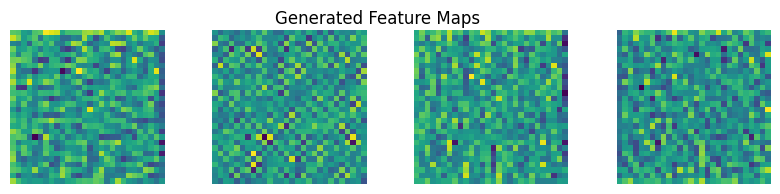

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

class CustomConv2D(tf.keras.layers.Layer): #tf.keras.layers.Layer is the base class provided by TensorFlow.
    def __init__(self, filters, kernel_size, **kwargs): #ensuring that the base Layer class is initialized correctly.
        super(CustomConv2D, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size

    def build(self, input_shape): # build is a method that TensorFlow calls automatically when it sees data for the first time.
        # Initialize kernel weights (height, width, input_channels, output_channels)
        # add_weight is a standard TensorFlow function that registers a tensor as a "trainable variable.

        self.w = self.add_weight(
            shape=(self.kernel_size, self.kernel_size, input_shape[-1], self.filters),
            initializer='glorot_uniform',
            trainable=True #trainable=True tells TensorFlow: "When the model learns, please adjust these numbers.
        )
        super(CustomConv2D, self).build(input_shape) #super() overrides the built in methods.

    def call(self, inputs): #call is the standard method name that TensorFlow calls to perform the "forward pass."
        # Perform the actual convolution
        return tf.nn.conv2d(inputs, self.w, strides=[1, 1, 1, 1], padding='SAME')
        #tf.nn.conv2d is a standard, highly optimized math function provided by the TensorFlow core.

# 1. Prepare a dummy image (Batch size 1, 28x28, 1 channel)
img = np.random.rand(1, 28, 28, 1).astype('float32')

# 2. Instantiate and run our custom layer
conv_layer = CustomConv2D(filters=4, kernel_size=3)
feature_maps = conv_layer(img)

# 3. Visualize
plt.figure(figsize=(10, 2))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle("Generated Feature Maps")
plt.show()

In [ ]:
# We saw how to build a layer. Now we connect them. In TensorFlow/Keras, we have two primary ways to do this.
# 1. Sequential: If your data flows from input to output without branching, this is the most readable and cleanest approach.
# Standard: tf.keras.models.Sequential
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [ ]:
#The Functional API (The "Graph")
#You use this for complex architectures where you need "shortcuts" (skip connections) or multiple inputs.
#You are writing the "Explicit Wiring"
# Standard: tf.keras.layers.Input and tf.keras.Model
inputs = tf.keras.layers.Input(shape=(28,28,1))
x = tf.keras.layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

# Functional allows us to "branch" the flow
x = tf.keras.layers.BatchNormalization()(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

As you stack more layers, the error signal (gradient) used for training shrinks as it travels backward through the network. Eventually, it becomes so small that the early layers stop learning entirely.

Instead of choosing between a $3 \times 3$ or $5 \times 5$ filter, it uses both in parallel and concatenates the results. This allows the network to learn both "fine" and "coarse" details simultaneously.

**ResNet** (Residual Networks): The industry standard. It introduced Skip Connections (also called Residual Blocks). These connections allow the gradient to "jump" over layers, effectively bypassing the Vanishing Gradient problem and allowing for networks with hundreds of layers.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

def residual_block(x, filters):
    # Save the input to add it back later (the "skip")
    shortcut = x

    # First convolution layer
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Second convolution layer
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # The Skip Connection: Adding the original input back
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets

# 1. Load and Preprocess CIFAR-10
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. Define a Residual Block (The "functional" building block)
def res_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut]) # The skip connection
    return layers.Activation('relu')(x)

# 3. Assemble the ResNet-lite Architecture
inputs = layers.Input(shape=(32, 32, 3))
x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
x = res_block(x, 32)
x = layers.MaxPooling2D(2)(x)
x = layers.Flatten()(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

# 4. Train
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# 5. Inference
# We take one image from the test set and see what the model thinks
import numpy as np
sample_image = x_test[0:1] # Shape: (1, 32, 32, 3)
prediction = model.predict(sample_image)
predicted_class = np.argmax(prediction)

print(f"Model predicted class: {predicted_class}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 301s 191ms/step - accuracy: 0.5065 - loss: 1.4611 - val_accuracy: 0.5768 - val_loss: 1.1962
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 287s 184ms/step - accuracy: 0.6449 - loss: 1.0179 - val_accuracy: 0.5825 - val_loss: 1.2188
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 333s 191ms/step - accuracy: 0.6930 - loss: 0.8813 - val_accuracy: 0.6665 - val_loss: 0.9583
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 293s 187ms/step - accuracy: 0.7236 - loss: 0.7941 - val_accuracy: 0.6772 - val_loss: 0.9416
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 328s 191ms/step - accuracy: 0.7516 - loss: 0.7192 - val_accuracy: 0.6801 - val_loss: 0.9338
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Model predicted class: 3
